# Hiperparametry estymatorow

## LS

In [12]:
import pandas as pd
df_ls = pd.read_csv("../tables/LS_test_results.csv")
df_ls.drop_duplicates(inplace=True)
df_ls.sort_values(by=['wspolczynnik odleglosci', "szerokosc okna"], inplace=True)
df_ls["blad sredni"] = df_ls["blad"]/303
df_ls.to_csv("../tables/LS_test_results.csv", index=False)

In [13]:
best_ls = df_ls[df_ls["blad"] == df_ls["blad"].min()]
best_ls

,Estymator,przyspieszenie,predkosc,wspolczynnik odleglosci,szerokosc okna,blad,blad sredni
539,LS,-,-,9.0,3,539.16,1.779406


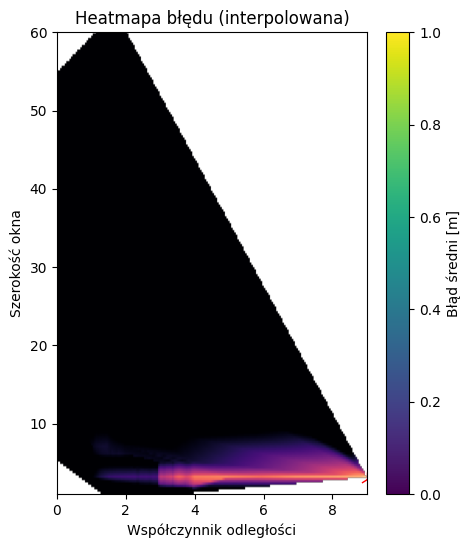

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.interpolate import griddata

x = df_ls["wspolczynnik odleglosci"].values
y = df_ls["szerokosc okna"].values
z = df_ls["blad sredni"].astype(float).values

# Tworzymy siatkę
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolacja
Zi = griddata((x, y), z, (Xi, Yi), method='linear')
norm = colors.PowerNorm(gamma=0.5, vmin=z.min(), vmax=2)
plt.figure(figsize=(5, 6))
plt.imshow(Zi, extent=[x.min(), x.max(), y.min(), y.max()],
           origin='lower', cmap='magma_r', aspect='auto', norm=norm)
plt.scatter(best_ls['wspolczynnik odleglosci'], best_ls['szerokosc okna'],marker="2",s=100, c="red", linewidth=1)
cbar = plt.colorbar()
cbar.set_label("Błąd średni [m]")


plt.xlabel("Współczynnik odległości")
plt.ylabel("Szerokość okna")
plt.title("Heatmapa błędu (interpolowana)")
plt.show()

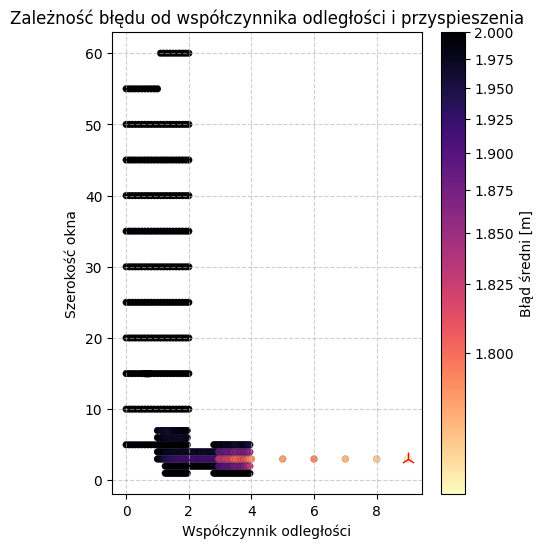

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 6))
sc = plt.scatter(df_ls["wspolczynnik odleglosci"], 
                 df_ls['szerokosc okna'], 
                 c=df_ls["blad sredni"].astype(float), 
                 cmap='magma_r', 
                 s=25,
                 edgecolor='black', 
                 norm=norm,
                 linewidth=0.1)
plt.scatter(best_ls['wspolczynnik odleglosci'], best_ls['szerokosc okna'],marker="2",s=100, c="red", linewidth=1)
cbar = plt.colorbar(sc)
cbar.set_label('Błąd średni [m]') 

plt.ylabel("Szerokość okna")
plt.xlabel("Współczynnik odległości")
plt.title("Zależność błędu od współczynnika odległości i przyspieszenia")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## DLS

In [5]:
import pandas as pd
df_dls = pd.read_csv("../tables/DLS_test_results.csv")
df_dls.drop_duplicates(inplace=True)
df_dls.sort_values(by=['wspolczynnik odleglosci', 'predkosc','szerokosc okna'], inplace=True)
df_dls["blad sredni"] = df_dls["blad"]/303
df_dls.to_csv("../tables/DLS_test_results.csv", index=False)

In [6]:
best_dls = df_dls[df_dls["blad"] == df_dls["blad"].min()]
best_dls

,Estymator,przyspieszenie,predkosc,wspolczynnik odleglosci,szerokosc okna,blad,blad sredni
1217,DLS,-,1.0,1.4,3,545.9,1.80165
1219,DLS,-,1.0,1.4,3,545.9,1.80165


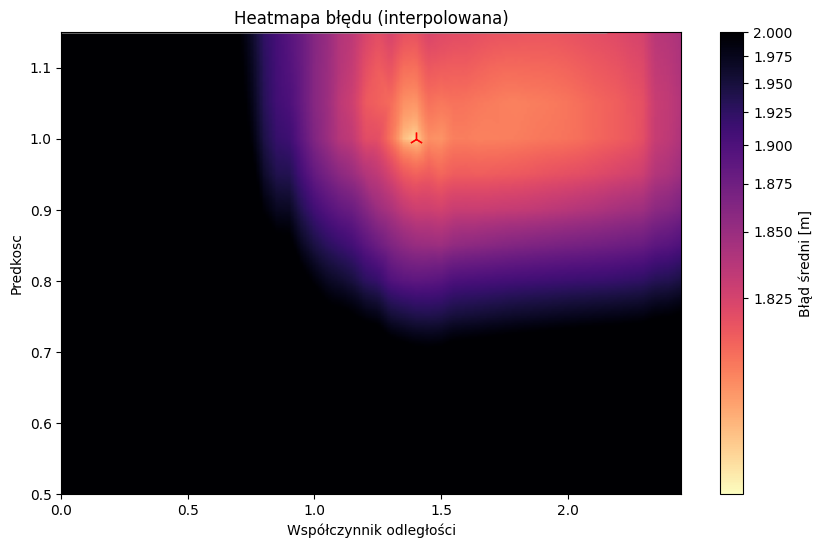

In [53]:
df_dls = df_dls[df_dls["szerokosc okna"]==3]
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

x = df_dls["wspolczynnik odleglosci"].values
y = df_dls['predkosc'].values
z = df_dls["blad sredni"].astype(float).values

# Tworzymy siatkę
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolacja
Zi = griddata((x, y), z, (Xi, Yi), method='linear')
norm = colors.PowerNorm(gamma=0.4, vmin=z.min(), vmax=2)
plt.figure(figsize=(10, 6))
plt.imshow(Zi, extent=[x.min(), x.max(), y.min(), y.max()],
           origin='lower', cmap='magma_r', aspect='auto', norm=norm)
cbar = plt.colorbar()
plt.scatter(best_dls['wspolczynnik odleglosci'], best_dls['predkosc'],marker="2",s=100, c="red", linewidth=1)
cbar.set_label("Błąd średni [m]")

plt.xlabel("Współczynnik odległości")
plt.ylabel("Predkosc")
plt.title("Heatmapa błędu (interpolowana)")
plt.show()

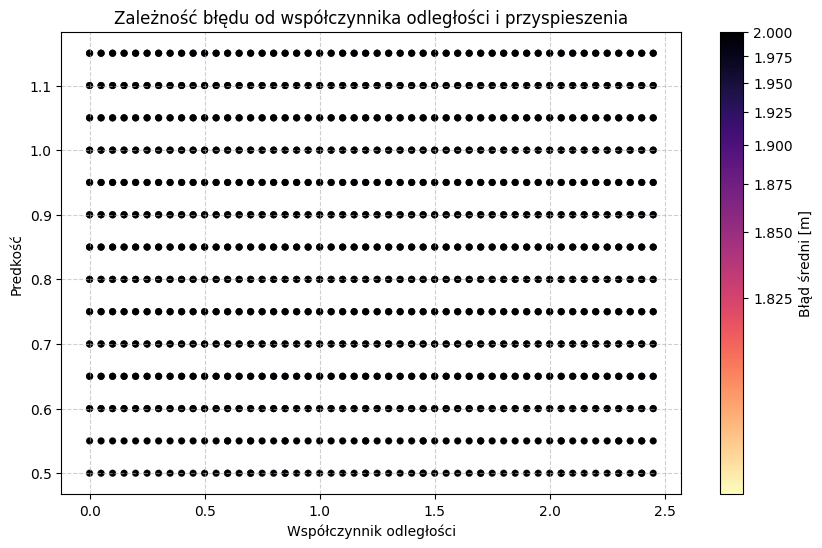

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sc = plt.scatter(df_dls["wspolczynnik odleglosci"], 
                 df_dls['predkosc'], 
                 c=df_dls['blad'].astype(float), 
                 cmap='magma_r', 
                 s=25,
                 edgecolor='black', 
                 linewidth=0.1,
                 norm=norm)

cbar = plt.colorbar(sc)
cbar.set_label('Błąd średni [m]') 

plt.ylabel("Predkość")
plt.xlabel("Współczynnik odległości")
plt.title("Zależność błędu od współczynnika odległości i przyspieszenia")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## D2LS

In [7]:
import pandas as pd
df_d2ls = pd.read_csv("../tables/D2LS_test_results.csv")
df_d2ls.drop_duplicates(inplace=True)
df_d2ls.sort_values(by=['wspolczynnik odleglosci', 'predkosc', 'przyspieszenie','szerokosc okna'], inplace=True)
df_d2ls.sort_values(by=['Estymator'],ascending=False)
df_d2ls["blad sredni"] = df_d2ls["blad"]/303
df_d2ls.to_csv("../tables/D2LS_test_results.csv", index=False)

In [8]:
df_d2ls= df_d2ls[df_d2ls["Estymator"]=="D2LS"]
best_d2ls = df_d2ls[df_d2ls["blad"] == df_d2ls["blad"].min()]
best_d2ls

,Estymator,przyspieszenie,predkosc,wspolczynnik odleglosci,szerokosc okna,blad,blad sredni
2120,D2LS,1.05,-,2.4,3,596.51,1.96868


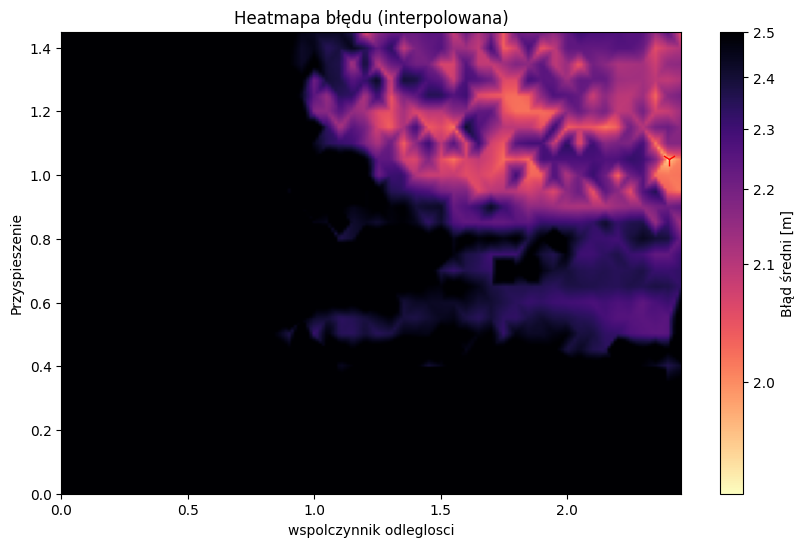

In [36]:
df_d2ls = df_d2ls[df_d2ls['szerokosc okna']==3]
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

x = df_d2ls['wspolczynnik odleglosci'].values
y = df_d2ls['przyspieszenie'].values
z = df_d2ls["blad sredni"].astype(float).values

# Tworzymy siatkę
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)
norm = colors.PowerNorm(gamma=0.5, vmin=z.min(), vmax=2.5)
# Interpolacja
Zi = griddata((x, y), z, (Xi, Yi), method='linear')

plt.figure(figsize=(10, 6))
plt.imshow(Zi, extent=[x.min(), x.max(), y.min(), y.max()],
           origin='lower', cmap='magma_r', aspect='auto',norm=norm)
cbar = plt.colorbar()
plt.scatter(best_d2ls['wspolczynnik odleglosci'], best_d2ls['przyspieszenie'], marker="1",s=100, c="red", linewidth=1)
cbar.set_label("Błąd średni [m]")
plt.xlabel("wspolczynnik odleglosci")
plt.ylabel("Przyspieszenie")
plt.title("Heatmapa błędu (interpolowana)")
plt.show()

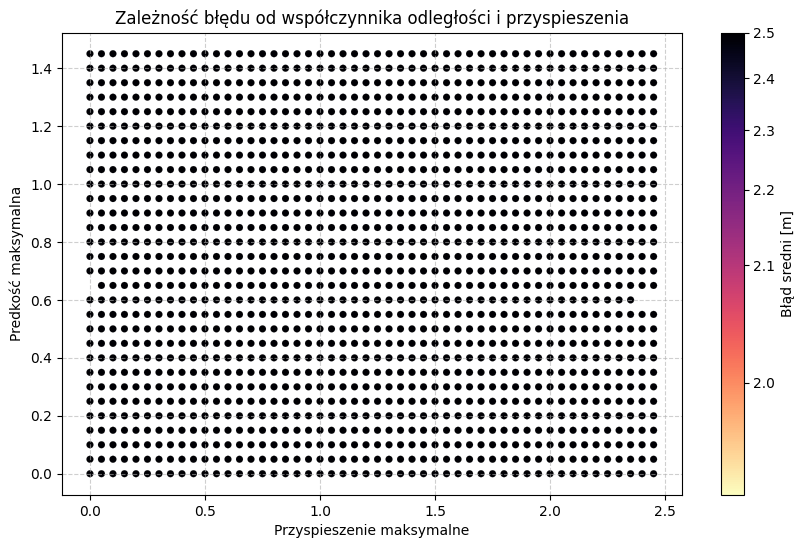

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sc = plt.scatter(df_d2ls['wspolczynnik odleglosci'], 
                 df_d2ls['przyspieszenie'],
                 c=df_d2ls['blad'].astype(float), 
                 cmap='magma_r', 
                 s=25,
                 edgecolor='black', 
                 linewidth=0.1,
                 norm=norm)

cbar = plt.colorbar(sc)
cbar.set_label('Błąd sredni [m]') 

plt.ylabel("Predkość maksymalna")
plt.xlabel("Przyspieszenie maksymalne")
plt.title("Zależność błędu od współczynnika odległości i przyspieszenia")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## DAMPING

In [38]:
import pandas as pd

df_d2lsd = pd.read_csv("../tables/D2LSD_test_results.csv")
df_d2lsd.sort_values(by=['wspolczynnik odleglosci', 'predkosc', 'przyspieszenie', 'wzmocnienie','szerokosc okna'], inplace=True)
df_d2lsd.drop_duplicates(inplace=True)
df_d2lsd["blad sredni"] = df_d2lsd["blad"]/303
df_d2lsd.to_csv("../tables/D2LSD_test_results.csv", index=False)

In [39]:
df_d2lsd =df_d2lsd[df_d2lsd['Estymator']=="D2LSD"]
df_d2lsd[df_d2lsd["blad"] <560]

,Estymator,przyspieszenie,predkosc,wspolczynnik odleglosci,wzmocnienie,szerokosc okna,blad,blad sredni
2341,D2LSD,2.6,-,1.0,-0.3,3,559.90,1.847855
2354,D2LSD,2.8,-,1.0,-0.3,3,559.31,1.845908
2474,D2LSD,1.2,-,1.2,0.5,3,559.85,1.847690
2486,D2LSD,1.4,-,1.2,0.3,3,557.58,1.840198
2499,D2LSD,1.6,-,1.2,0.3,3,554.97,1.831584
...,...,...,...,...,...,...,...,...
3894,D2LSD,2.8,-,2.4,-0.3,3,555.15,1.832178
3895,D2LSD,2.8,-,2.4,-0.1,3,558.74,1.844026
3896,D2LSD,2.8,-,2.4,0.1,3,559.93,1.847954
3897,D2LSD,2.8,-,2.4,0.3,3,559.49,1.846502


In [40]:
df_d2lsd =df_d2lsd[df_d2lsd['Estymator']=="D2LSD"]
df_d2lsd =df_d2lsd[df_d2lsd['szerokosc okna']==3]
best_damp = df_d2lsd[df_d2lsd["blad"] == df_d2lsd["blad"].min()]
best_damp

,Estymator,przyspieszenie,predkosc,wspolczynnik odleglosci,wzmocnienie,szerokosc okna,blad,blad sredni
2793,D2LSD,2.8,-,1.4,-0.5,3,544.29,1.796337


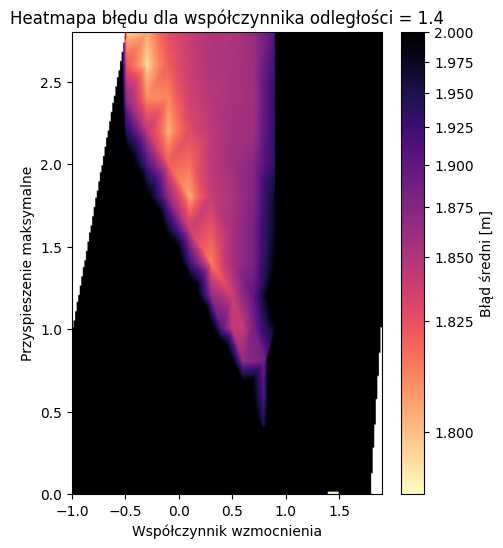

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors 
from scipy.interpolate import griddata
df_d2lsd =df_d2lsd[df_d2lsd['wspolczynnik odleglosci']==best_damp['wspolczynnik odleglosci'].values[0]]
x = df_d2lsd['wzmocnienie'].values
y = df_d2lsd['przyspieszenie'].values
z = df_d2lsd["blad sredni"].astype(float).values

# Tworzymy siatkę
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolacja
Zi = griddata((x, y), z, (Xi, Yi), method='linear')


plt.figure(figsize=(5, 6))

# Kluczowa zmiana: dodajemy parametr norm
norm = colors.PowerNorm(gamma=0.5, vmin=z.min(), vmax=2)
plt.imshow(Zi, 
           extent=[x.min(), x.max(), y.min(), y.max()],
           origin='lower', 
           cmap='magma_r', 
           aspect='auto',
           norm=norm)

cbar = plt.colorbar()
cbar.set_label("Błąd średni [m]")

# Reszta wykresu
plt.scatter(best_damp['wzmocnienie'], best_damp['przyspieszenie'], 
            marker="1", s=100, c="red", linewidth=1)

plt.xlabel("Współczynnik wzmocnienia")
plt.ylabel("Przyspieszenie maksymalne")
plt.title(f"Heatmapa błędu dla współczynnika odległości = {best_damp['wspolczynnik odleglosci'].values[0]}")
plt.show()




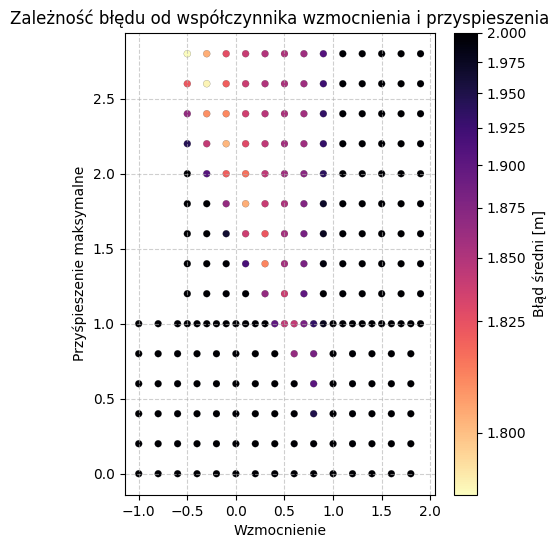

In [55]:
plt.figure(figsize=(5, 6))
sc = plt.scatter(df_d2lsd['wzmocnienie'], 
                 df_d2lsd['przyspieszenie'],
                 c=df_d2lsd['blad sredni'].astype(float), 
                 cmap='magma_r', 
                 s=25,
                 edgecolor='black', 
                 linewidth=0.1,
                 norm=norm)

cbar = plt.colorbar(sc)
cbar.set_label('Błąd średni [m]') 

plt.xlabel("Wzmocnienie")
plt.ylabel("Przyśpieszenie maksymalne")
plt.title("Zależność błędu od współczynnika wzmocnienia i przyspieszenia")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()